In [1]:
# =============================================================================
# 12a — Brush annotation QC
#
# Purpose
#   Validate clinician brush masks before any overlap analysis.
#   Nothing downstream is trustworthy until this notebook is clean.
#
# Writes
#   results/annotation_qc/annotation_qc_manifest.csv
#   results/annotation_qc/curated_case_lookup.csv
# =============================================================================
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import cv2
from PIL import Image
import matplotlib.pyplot as plt


def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError("Could not find repo root.")


REPO = find_repo_root()
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.eval.cam_eval_utils import (
    resize_centercrop_mask, mask_to_cam_grid,
    canonical_label, label_group,
    RESIZE_SHORT, CROP_SIZE, CAM_GRID,
)

ANN_DIR   = REPO / "data" / "brush_annotation_masks"
ANN_CSV   = ANN_DIR / "brush_annotation_summary.csv"
HAM_ROOT  = REPO / "data" / "HAM10000"
CLEAN_CSV = HAM_ROOT / "mel_nv" / "ham_mel_nv_clean.csv"

OUT_DIR = REPO / "results" / "annotation_qc"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# QC thresholds
MIN_PATCH_50   = 1      # at least one patch at least half covered at 14x14
MIN_CROP_KEEP  = 0.80   # at least 80 percent of the annotation survives the crop

print("REPO:", REPO)
for p in [ANN_DIR, ANN_CSV, CLEAN_CSV]:
    print(f"{'OK      ' if p.exists() else 'MISSING '} {p}")
print(f"\ngrid {CAM_GRID}x{CAM_GRID} | resize {RESIZE_SHORT} | crop {CROP_SIZE}")

REPO: /storage/homefs/cn21m021/projects/master-thesis
OK       /storage/homefs/cn21m021/projects/master-thesis/data/brush_annotation_masks
OK       /storage/homefs/cn21m021/projects/master-thesis/data/brush_annotation_masks/brush_annotation_summary.csv
OK       /storage/homefs/cn21m021/projects/master-thesis/data/HAM10000/mel_nv/ham_mel_nv_clean.csv

grid 14x14 | resize 256 | crop 224


In [2]:
# =============================================================================
# The whole alignment rests on knowing the exact eval transform.
# Print it rather than assume it.
#
# EXPECT: Resize(size=256) then CenterCrop(size=(224, 224)).
# If Resize shows (256, 256) as a tuple the aspect ratio is squashed,
# and resize_centercrop_mask must be changed to match. Tell me if so.
# =============================================================================
sys.path.insert(0, str(REPO / "external" / "PanDerm" / "classification"))
from models.builder import get_eval_transforms

tf = get_eval_transforms(which_img_norm="imagenet", img_resize=256, center_crop=True)
print(tf)

normalization method:  imagenet
Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.228, 0.224, 0.225))
)


/storage/homefs/cn21m021/.conda/envs/thesis/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/storage/homefs/cn21m021/.conda/envs/thesis/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [ ]:
ann = pd.read_csv(ANN_CSV)
ann["Image_ID"] = ann["Image_ID"].astype(str).str.strip()
ann["Label_ID"] = ann["Label_ID"].astype(str).str.strip()
ann["Label_ID"]   = ann["Label_ID"].astype(str).str.strip()
ann["Label_Name"] = ann["Label_Name"].astype(str).str.strip()
ann["label"] = [canonical_label(a, b)
                for a, b in zip(ann["Label_ID"], ann["Label_Name"])]

print(f"rows {len(ann)}   images {ann['Image_ID'].nunique()}   "
      f"labels {ann['label'].nunique()}")
print()
print(ann[["Image_ID", "label", "Stroke_Count"]].head(6).to_string(index=False))
print()
print("annotations per label:")
print(ann["label"].value_counts().to_string())

print(f"rows {len(ann)}   images {ann['Image_ID'].nunique()}   "
      f"labels {ann['Label_ID'].nunique()}")
print()
print(ann.head(6).to_string(index=False))
print()
print("annotations per label:")
print(ann["Label_ID"].value_counts().to_string())
print()
print("annotations per image:")
print(ann.groupby("Image_ID").size().describe().round(2).to_string())
print()
print("stroke count:")
print(ann["Stroke_Count"].describe().round(2).to_string())

zero_strokes = ann[ann["Stroke_Count"] == 0]
print(f"\nzero stroke rows: {len(zero_strokes)}")
if len(zero_strokes):
    print(zero_strokes[["Image_ID", "Label_ID"]].to_string(index=False))

rows 105   images 34   labels 15

    Image_ID                     label  Stroke_Count
ISIC_0024756             atypical_dots            10
ISIC_0024756        structureless_area             3
ISIC_0024756 atypical_vascular_pattern             1
ISIC_0024886          atypical_network             2
ISIC_0024886        structureless_area             1
ISIC_0024886         diagnostic_region             4

annotations per label:
label
structureless_area                                   29
atypical_network                                     16
atypical_dots                                        11
regression                                            9
blue_white_structureless_area                         9
regular_network                                       5
regression_scar_like_depigmentation_and_peppering     4
atypical_streaks                                      4
atypical_vascular_pattern                             3
diagnostic_region                                     3
peppe

In [4]:
def resolve_mask(fname):
    direct = ANN_DIR / str(fname)
    if direct.exists():
        return direct
    hits = list(ANN_DIR.rglob(str(fname)))
    return hits[0] if hits else None


ann["mask_path"] = ann["Mask_Filename"].map(resolve_mask)
ann["mask_found"] = ann["mask_path"].notna()

print(f"resolved {int(ann['mask_found'].sum())} / {len(ann)}")
missing = ann[~ann["mask_found"]]
if len(missing):
    print("\nUNRESOLVED, stop and fix before continuing")
    print(missing[["Image_ID", "label", "Mask_Filename"]].to_string(index=False))
else:
    print("all mask files resolved")

# also check for orphan PNGs not listed in the CSV
listed = set(ann["Mask_Filename"].astype(str))
on_disk = {p.name for p in ANN_DIR.rglob("*.png")}
orphans = sorted(on_disk - listed)
print(f"\nPNGs on disk not in CSV: {len(orphans)}")
if orphans:
    print(orphans[:10])

resolved 105 / 105
all mask files resolved

PNGs on disk not in CSV: 0


In [5]:
# =============================================================================
# The 08b export manifest was never written, since those cells were
# commented out. Recover case types by searching for the subset CSVs.
# =============================================================================
SUBSET_PATTERNS = {
    "TP_MEL":                "*typical_mel*.csv",
    "TN_NV":                 "*typical_nv*.csv",
    "FN_MEL":                "*fn_mel*.csv",
    "FP_MEL":                "*fp_mel*.csv",
    "DIFFICULT_CORRECT_MEL": "*difficult_correct_mel*.csv",
}

search_root = REPO / "outputs"
frames = []
for case_label, pattern in SUBSET_PATTERNS.items():
    hits = [p for p in search_root.rglob(pattern) if p.is_file()]
    if not hits:
        print(f"  not found: {case_label}")
        continue
    p = sorted(hits, key=lambda x: len(str(x)))[0]
    d = pd.read_csv(p)
    if "image_id" not in d.columns:
        print(f"  no image_id column in {p.name}")
        continue
    d["image_id"] = d["image_id"].astype(str).str.strip()
    d["case_type"] = case_label
    keep = [c for c in ["image_id", "gt_label", "selection_reason", "case_type"]
            if c in d.columns]
    frames.append(d[keep])
    print(f"  {case_label:<24} {len(d):>3} rows   {p.relative_to(REPO)}")

if frames:
    curated = pd.concat(frames, ignore_index=True)
    dup_across = curated[curated.duplicated("image_id", keep=False)]
    if len(dup_across):
        print(f"\nimages in more than one subset: "
              f"{dup_across['image_id'].nunique()}")
        print(dup_across.sort_values("image_id")
              [["image_id", "case_type"]].to_string(index=False))
    curated = curated.drop_duplicates("image_id", keep="first")
    curated.to_csv(OUT_DIR / "curated_case_lookup.csv", index=False)
    print(f"\ncurated lookup rows: {len(curated)}")
else:
    curated = None
    print("\nNo subset CSVs found. Case types will be missing.")

  not found: TP_MEL
  not found: TN_NV
  not found: FN_MEL
  not found: FP_MEL
  not found: DIFFICULT_CORRECT_MEL

No subset CSVs found. Case types will be missing.


In [6]:
# =============================================================================
# One loop, every measurement. Avoids merge key bugs entirely.
# =============================================================================
clean = pd.read_csv(CLEAN_CSV).drop_duplicates("image_id")
clean["image_id"] = clean["image_id"].astype(str).str.strip()
img_lookup    = clean.set_index("image_id")["image_rel_path"].to_dict()
lesion_lookup = clean.set_index("image_id")["mask_rel_path"].to_dict()

_lesion_cache = {}


def load_lesion(image_id, shape):
    if image_id in _lesion_cache:
        return _lesion_cache[image_id]
    rel = lesion_lookup.get(image_id)
    out = None
    if rel is not None:
        p = (HAM_ROOT / str(rel)).resolve()
        if p.exists():
            m = Image.open(p).convert("L").resize((shape[1], shape[0]), Image.NEAREST)
            out = np.array(m) > 127
    _lesion_cache[image_id] = out
    return out


records = []
for _, r in ann.iterrows():
    rec = {
        "Image_ID":      r["Image_ID"],
        "Annotation_ID": r["Annotation_ID"],
        "Stroke_Count":  r["Stroke_Count"],
        "mask_found":    bool(r["mask_found"]),
        "mask_path":     str(r["mask_path"]) if r["mask_found"] else "",
        "Label_ID":      r["Label_ID"],
        "Label_Name":    r["Label_Name"],
        "label":         r["label"],
    }

    if not r["mask_found"]:
        records.append(rec)
        continue

    raw = np.array(Image.open(r["mask_path"]).convert("L"))
    vals = np.unique(raw)
    m = raw > 127

    rec.update({
        "mask_h": int(raw.shape[0]),
        "mask_w": int(raw.shape[1]),
        "n_grey_levels": int(len(vals)),
        "px_positive": int(m.sum()),
        "area_frac": float(m.mean()),
    })

    if m.sum() == 0:
        records.append(rec)
        continue

    crop, kept = resize_centercrop_mask(m)
    grid = mask_to_cam_grid(crop, already_cropped=True)

    lesion = load_lesion(r["Image_ID"], m.shape)
    inside = float((m & lesion).sum() / m.sum()) if lesion is not None else np.nan

    rec.update({
        "frac_kept_after_crop": kept,
        "px_after_crop":        int(crop.sum()),
        "area_frac_cropped":    float(crop.mean()),
        "grid_sum":             float(grid.sum()),
        "grid_max":             float(grid.max()),
        "n_patch_50":           int((grid >= 0.5).sum()),
        "n_patch_any":          int((grid > 0.01).sum()),
        "grid_area_frac":       float((grid >= 0.5).mean()),
        "frac_inside_lesion":   inside,
    })
    records.append(rec)

qc = pd.DataFrame(records)
# qc["label_group"] = qc["Label_ID"].map(label_group)
qc["label_group"] = qc["label"].map(label_group)

print(f"measured {len(qc)} annotations")
print()
print("mask resolutions:")
print(qc.groupby(["mask_h", "mask_w"]).size().to_string())
print()
print("grey levels per mask:")
print(qc["n_grey_levels"].value_counts().to_string())
print()
print("label groups:")
print(qc["label_group"].value_counts().to_string())

unknown = sorted(qc.loc[qc.label_group == "UNKNOWN", "Label_ID"].unique())
if unknown:
    print(f"\nUNKNOWN labels, add them to LABEL_GROUPS: {unknown}")

print("\ncanonical label mapping:")
print(qc[["Label_Name", "label", "label_group"]]
      .drop_duplicates()
      .sort_values(["label_group", "label"])
      .to_string(index=False))

n_unknown = int((qc.label_group == "UNKNOWN").sum())
print(f"\nUNKNOWN: {n_unknown}")
assert n_unknown == 0, "unmapped labels remain"

measured 105 annotations

mask resolutions:
mask_h  mask_w
450     600       105

grey levels per mask:
n_grey_levels
2    105

label groups:
label_group
MEL       89
NV         8
OTHER      5
COARSE     3

canonical label mapping:
                                       Label_Name                                             label label_group
                                Diagnostic region                                 diagnostic_region      COARSE
                                    Atypical dots                                     atypical_dots         MEL
                                 Atypical network                                  atypical_network         MEL
                                 Atypical streaks                                  atypical_streaks         MEL
                        Atypical vascular pattern                         atypical_vascular_pattern         MEL
                    Blue-white structureless area                     blue_white_structureless_a

In [ ]:
# =============================================================================
# HAM is 450x600. Resize to short side 256 gives 256x341.
# CenterCrop 224 then removes ~58 px each side horizontally.
# In original coordinates that is roughly 103 px off each side of 600.
#
# EXPECT: median close to 1.00 for most labels, since lesions are centred.
# WATCH:  any label with min well below 0.8 was drawn near the edge and
#         is partly invisible to the CAM.
# =============================================================================
print("fraction surviving the centre crop, by label:")
print(qc.groupby("label")["frac_kept_after_crop"]
      .agg(["count", "median", "min"]).round(3).to_string())

lost = qc[qc["frac_kept_after_crop"] < MIN_CROP_KEEP]
print(f"\nannotations losing more than {int((1-MIN_CROP_KEEP)*100)} percent: {len(lost)}")
if len(lost):
    print(lost[["Image_ID", "label", "frac_kept_after_crop", "px_positive"]]
          .sort_values("frac_kept_after_crop").round(3).to_string(index=False))

fraction surviving the centre crop, by label:
                                                   count  median    min
label                                                                  
atypical_dots                                         11     1.0  1.000
atypical_network                                      16     1.0  0.764
atypical_streaks                                       4     1.0  0.743
atypical_vascular_pattern                              3     1.0  1.000
blue_white_structureless_area                          9     1.0  1.000
diagnostic_region                                      3     1.0  1.000
homogeneous                                            3     1.0  0.954
negative_network                                       1     1.0  1.000
peppering                                              3     1.0  1.000
preminent_skin_markings                                3     1.0  1.000
regression                                             9     1.0  0.882
regression_scar_li

In [8]:
# =============================================================================
# Sensitivity: does relaxing the crop threshold change anything.
# 2 annotations out of 105, so expect no movement.
# =============================================================================
for thr in [0.80, 0.75, 0.70]:
    p = qc[
        qc.mask_found
        & (qc.px_positive.fillna(0) > 0)
        & (qc.n_patch_50.fillna(0) >= 1)
        & (qc.frac_kept_after_crop.fillna(0) >= thr)
    ]
    print(f"threshold {thr:.2f}  annotations {len(p):3d}  "
          f"MEL {int((p.label_group=='MEL').sum()):3d}  "
          f"images {p.Image_ID.nunique()}")

threshold 0.80  annotations 102  MEL  86  images 34
threshold 0.75  annotations 103  MEL  87  images 34
threshold 0.70  annotations 104  MEL  88  images 34


In [9]:
# =============================================================================
# A 14x14 grid over a 224 crop means each patch is 16x16 pixels.
# An annotation smaller than about one patch cannot be scored.
#
# EXPECT: diagnostic_region and structureless_area large, many patches.
#         atypical_dots and vascular_pattern small, possibly 1 to 3 patches.
# WATCH:  any label whose median n_patch_50 is 0 must be dropped.
# =============================================================================
print("effective coverage at CAM resolution, by label:")
print(qc.groupby("label")[["grid_sum", "n_patch_50", "n_patch_any"]]
      .agg(["median", "min", "max"]).round(2).to_string())

dead = qc[(qc["px_positive"] > 0) & (qc["n_patch_50"] == 0)]
print(f"\nannotations with zero half-covered patches: {len(dead)}")
if len(dead):
    print(dead[["Image_ID", "label", "px_positive", "grid_sum", "grid_max"]]
          .round(3).to_string(index=False))

print("\narea fraction at grid resolution, by group:")
print(qc.groupby("label_group")["grid_area_frac"]
      .agg(["count", "median", "max"]).round(3).to_string())

effective coverage at CAM resolution, by label:
                                                  grid_sum                n_patch_50          n_patch_any         
                                                    median    min     max     median min  max      median min  max
label                                                                                                             
atypical_dots                                         2.26   1.21   35.82        2.0   1   38         9.0   4   65
atypical_network                                     25.23   2.35  115.93       23.0   1  111        41.0   9  150
atypical_streaks                                     10.01   3.70   22.82       10.0   3   22        18.5   8   53
atypical_vascular_pattern                            13.35  11.08   14.88       13.0   9   14        25.0  24   25
blue_white_structureless_area                         4.95   2.84   17.82        4.0   2   17        12.0   8   29
diagnostic_region               

In [10]:
# =============================================================================
# EXPECT: clinical feature labels near 1.00, they sit inside the lesion.
#         artifact_ignore LOW, it marks hair, rulers, bubbles outside.
# WATCH:  a clinical label well below 0.9 suggests a registration problem.
# =============================================================================
print("fraction of annotation inside the Tschandl lesion mask:")
print(qc.groupby("label")["frac_inside_lesion"]
      .agg(["count", "median", "min"]).round(3).to_string())
print()
print("by group:")
print(qc.groupby("label_group")["frac_inside_lesion"]
      .agg(["count", "median"]).round(3).to_string())

odd = qc[(qc["label_group"].isin(["MEL", "NV", "COARSE"])) &
         (qc["frac_inside_lesion"] < 0.7)]
print(f"\nclinical labels less than 70 percent inside the lesion: {len(odd)}")
if len(odd):
    print(odd[["Image_ID", "label", "frac_inside_lesion"]]
          .round(3).to_string(index=False))

fraction of annotation inside the Tschandl lesion mask:
                                                   count  median    min
label                                                                  
atypical_dots                                         11   1.000  0.876
atypical_network                                      16   0.999  0.879
atypical_streaks                                       4   0.980  0.959
atypical_vascular_pattern                              3   1.000  0.967
blue_white_structureless_area                          9   1.000  1.000
diagnostic_region                                      3   1.000  1.000
homogeneous                                            3   1.000  0.972
negative_network                                       1   1.000  1.000
peppering                                              3   1.000  1.000
preminent_skin_markings                                3   0.992  0.981
regression                                             9   1.000  0.993
regressi

In [11]:
dup = (qc.groupby(["Image_ID", "label"]).size()
         .reset_index(name="n").query("n > 1"))
print(f"image-label pairs with multiple annotations: {len(dup)}")
if len(dup):
    print(dup.to_string(index=False))
    print("These get merged by union in 12c.")

rows = []
for img, grp in qc[qc.mask_found & (qc.px_positive > 0)].groupby("Image_ID"):
    recs = grp.to_dict("records")
    masks = {i: np.array(Image.open(r["mask_path"]).convert("L")) > 127
             for i, r in enumerate(recs)}
    for i in range(len(recs)):
        for j in range(i + 1, len(recs)):
            u = (masks[i] | masks[j]).sum()
            if u == 0:
                continue
            rows.append({
                "Image_ID": img,
                "label_a": recs[i]["label"],
                "label_b": recs[j]["label"],
                "iou": float((masks[i] & masks[j]).sum() / u),
            })

ov = pd.DataFrame(rows)
if len(ov):
    print(f"\nlabel pairs compared: {len(ov)}")
    print(f"median IoU: {ov['iou'].median():.3f}")
    print("\nhighest overlaps:")
    print(ov.nlargest(10, "iou").round(3).to_string(index=False))
    ov.to_csv(OUT_DIR / "label_pair_overlap.csv", index=False)

image-label pairs with multiple annotations: 0

label pairs compared: 130
median IoU: 0.018

highest overlaps:
    Image_ID                       label_a                       label_b   iou
ISIC_0024886             diagnostic_region     small_hyperpigmented_area 0.673
ISIC_0024967                    regression blue_white_structureless_area 0.623
ISIC_0026491            structureless_area blue_white_structureless_area 0.532
ISIC_0026584            structureless_area             diagnostic_region 0.412
ISIC_0026584              negative_network             diagnostic_region 0.306
ISIC_0031565       preminent_skin_markings            structureless_area 0.299
ISIC_0032143            structureless_area             diagnostic_region 0.253
ISIC_0032462       preminent_skin_markings            structureless_area 0.112
ISIC_0032143             diagnostic_region     small_hyperpigmented_area 0.108
ISIC_0027420 blue_white_structureless_area              atypical_network 0.104


In [ ]:
if curated is not None:
    sent = set(curated["image_id"])
    got  = set(qc["Image_ID"])

    print(f"curated and sent  : {len(sent)}")
    print(f"returned annotated: {len(got)}")
    print(f"not returned      : {len(sent - got)}")
    if sent - got:
        print("  ", sorted(sent - got))
    if got - sent:
        print(f"annotated but not in any subset: {sorted(got - sent)}")

    cov = curated[curated["image_id"].isin(got)]
    print("\nannotated by case type:")
    print(cov["case_type"].value_counts().to_string())
    if "gt_label" in cov.columns:
        print("\nannotated by ground truth:")
        print(cov["gt_label"].value_counts().to_string())

    qc["case_type"] = qc["Image_ID"].map(
        curated.set_index("image_id")["case_type"])
    if "gt_label" in curated.columns:
        qc["gt_label"] = qc["Image_ID"].map(
            curated.set_index("image_id")["gt_label"])
else:
    qc["case_type"] = np.nan
    qc["gt_label"] = qc["Image_ID"].map(
        clean.set_index("image_id")["gt_label"]
        if "gt_label" in clean.columns else {})
    print("using gt_label from the clean CSV, case_type unavailable")

print("\nMEL images annotated:",
      qc.loc[qc.gt_label == "MEL", "Image_ID"].nunique()
      if "gt_label" in qc.columns else "unknown")

using gt_label from the clean CSV, case_type unavailable

MEL images annotated: 16


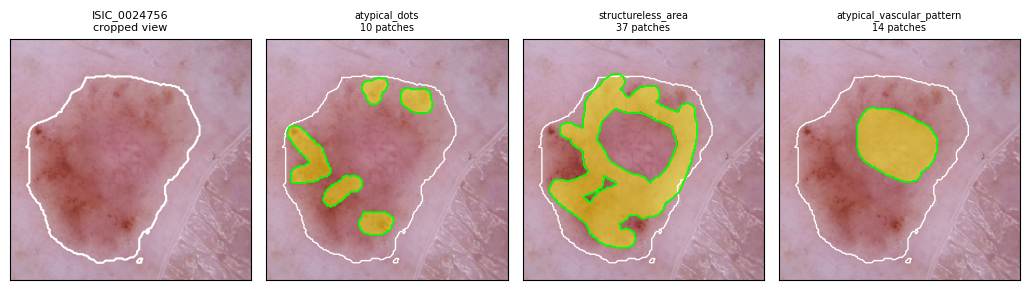

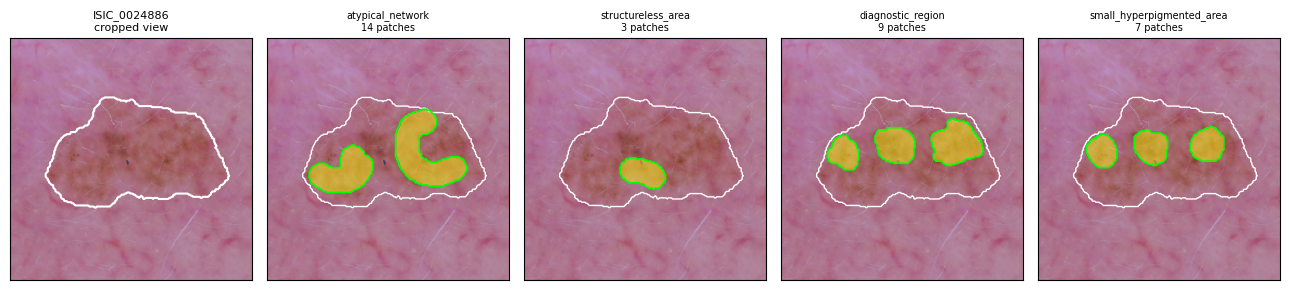

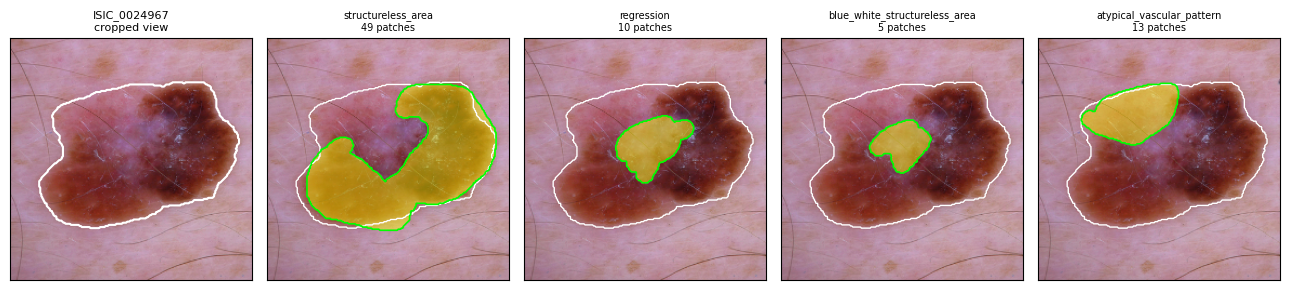

In [13]:
# =============================================================================
# FIGURE. One row per image. Column 0 is the original with the lesion
# outline in white. Remaining columns are the crop-aligned annotations,
# red fill with a green outline, over the SAME cropped view the CAM sees.
#
# EXPECT: red regions sit on the named feature and inside the white lesion
#         outline. artifact_ignore may sit outside, which is correct.
# WATCH:  a mask that looks shifted or mirrored means a coordinate bug.
# =============================================================================
def show_annotations(image_id, max_cols=6):
    rel = img_lookup.get(image_id)
    img = np.array(Image.open((HAM_ROOT / str(rel)).resolve()).convert("RGB"))

    scale = RESIZE_SHORT / min(img.shape[:2])
    nh, nw = int(round(img.shape[0]*scale)), int(round(img.shape[1]*scale))
    rgb = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR)
    top, left = (nh - CROP_SIZE)//2, (nw - CROP_SIZE)//2
    rgb = rgb[top:top+CROP_SIZE, left:left+CROP_SIZE]

    les = load_lesion(image_id, img.shape[:2])
    les_c = resize_centercrop_mask(les)[0] if les is not None else None

    sub = qc[(qc.Image_ID == image_id) & qc.mask_found & (qc.px_positive > 0)]
    n = len(sub) + 1
    ncol = min(max_cols, n)
    nrow = int(np.ceil(n / ncol))

    fig, axes = plt.subplots(nrow, ncol, figsize=(2.6*ncol, 2.9*nrow))
    axes = np.atleast_1d(axes).ravel()

    axes[0].imshow(rgb)
    if les_c is not None:
        axes[0].contour(les_c.astype(float), [0.5], colors="white", linewidths=1.5)
    axes[0].set_title(f"{image_id}\ncropped view", fontsize=8)

    for ax, (_, r) in zip(axes[1:], sub.iterrows()):
        m = np.array(Image.open(r["mask_path"]).convert("L")) > 127
        mc, _ = resize_centercrop_mask(m)
        ax.imshow(rgb)
        if les_c is not None:
            ax.contour(les_c.astype(float), [0.5], colors="white", linewidths=1.0)
        ax.imshow(np.ma.masked_where(~mc, mc.astype(float)),
                  cmap="autumn", alpha=0.45, vmin=0, vmax=1)
        ax.contour(mc.astype(float), [0.5], colors="lime", linewidths=1.2)
        ax.set_title(f"{r['label']}\n{r['n_patch_50']} patches", fontsize=7)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


for iid in qc["Image_ID"].drop_duplicates().head(3):
    show_annotations(iid)

In [14]:
qc["qc_pass"] = (
    qc["mask_found"]
    & (qc["px_positive"].fillna(0) > 0)
    & (qc["n_patch_50"].fillna(0) >= MIN_PATCH_50)
    & (qc["frac_kept_after_crop"].fillna(0) >= MIN_CROP_KEEP)
)

out = OUT_DIR / "annotation_qc_manifest.csv"
qc.to_csv(out, index=False)

print(f"written: {out}")
print(f"\ntotal {len(qc)}   passing {int(qc['qc_pass'].sum())}")
print()
print(qc.groupby(["label_group", "label"])["qc_pass"]
      .agg(n="size", passing="sum").to_string())
print()
print("failure reasons:")
print(f"  mask not found     : {int((~qc.mask_found).sum())}")
print(f"  empty mask         : {int((qc.px_positive.fillna(0) == 0).sum())}")
print(f"  lost at 14x14      : {int((qc.n_patch_50.fillna(0) < MIN_PATCH_50).sum())}")
print(f"  cropped away       : {int((qc.frac_kept_after_crop.fillna(0) < MIN_CROP_KEEP).sum())}")

written: /storage/homefs/cn21m021/projects/master-thesis/results/annotation_qc/annotation_qc_manifest.csv

total 105   passing 102

                                                                n  passing
label_group label                                                         
COARSE      diagnostic_region                                   3        3
MEL         atypical_dots                                      11       11
            atypical_network                                   16       15
            atypical_streaks                                    4        3
            atypical_vascular_pattern                           3        3
            blue_white_structureless_area                       9        9
            negative_network                                    1        1
            peppering                                           3        2
            regression                                          9        9
            regression_scar_like_depigmenta

In [15]:
print("=" * 64)
print("QC SUMMARY")
print("=" * 64)
p = qc[qc.qc_pass]
print(f"images annotated        : {qc['Image_ID'].nunique()}")
print(f"images with usable data : {p['Image_ID'].nunique()}")
print(f"annotations total       : {len(qc)}")
print(f"annotations passing     : {len(p)}")
print()
print(f"mask resolution         : {set(zip(qc.mask_h.dropna().astype(int), qc.mask_w.dropna().astype(int)))}")
print(f"usable by group         : {p['label_group'].value_counts().to_dict()}")
if "gt_label" in qc.columns:
    print(f"usable images by class  : "
          f"{p.drop_duplicates('Image_ID')['gt_label'].value_counts().to_dict()}")
print()
print("median grid area fraction by group, this is the chance baseline:")
print(p.groupby("label_group")["grid_area_frac"].median().round(3).to_string())
print()
n_mel_img = p.loc[p.get('gt_label') == 'MEL', 'Image_ID'].nunique() if 'gt_label' in p else 0
print(f"E1 sample size, all images : {p['Image_ID'].nunique()}")
print(f"E2 sample size, MEL only   : {n_mel_img}")

QC SUMMARY
images annotated        : 34
images with usable data : 34
annotations total       : 105
annotations passing     : 102

mask resolution         : {(450, 600)}
usable by group         : {'MEL': 86, 'NV': 8, 'OTHER': 5, 'COARSE': 3}
usable images by class  : {'NV': 18, 'MEL': 16}

median grid area fraction by group, this is the chance baseline:
label_group
COARSE    0.087
MEL       0.066
NV        0.184
OTHER     0.066

E1 sample size, all images : 34
E2 sample size, MEL only   : 16


In [16]:
# =============================================================================
# Union masks per image and per group. This is the real E1/E2 target.
#
# EXPECT: MEL union larger than any single label, since features stack.
# WATCH:  if the median union area fraction approaches 0.5, the chance
#         baseline is high and overlap metrics lose discriminative power.
# =============================================================================
from src.eval.cam_eval_utils import mask_to_cam_grid

rows = []
for (img, grp), sub in p.groupby(["Image_ID", "label_group"]):
    acc = None
    for _, r in sub.iterrows():
        m = np.array(Image.open(r["mask_path"]).convert("L")) > 127
        acc = m if acc is None else (acc | m)
    crop, _ = resize_centercrop_mask(acc)
    grid = mask_to_cam_grid(crop, already_cropped=True)
    rows.append({
        "Image_ID": img,
        "label_group": grp,
        "n_labels": len(sub),
        "union_patches_50": int((grid >= 0.5).sum()),
        "union_area_frac": float((grid >= 0.5).mean()),
    })

uni = pd.DataFrame(rows)
uni.to_csv(OUT_DIR / "union_masks_summary.csv", index=False)

print("union mask size by group:")
print(uni.groupby("label_group")[["n_labels", "union_patches_50", "union_area_frac"]]
      .agg(["count", "median", "min", "max"]).round(3).to_string())

mel = uni[uni.label_group == "MEL"]
print(f"\nMEL union, {len(mel)} images")
print(f"  median area fraction : {mel.union_area_frac.median():.3f}")
print(f"  range                : {mel.union_area_frac.min():.3f} to "
      f"{mel.union_area_frac.max():.3f}")
print(f"  images above 0.40    : {int((mel.union_area_frac > 0.40).sum())}")

union mask size by group:
            n_labels                union_patches_50                 union_area_frac                     
               count median min max            count median min  max           count median    min    max
label_group                                                                                              
COARSE             3    1.0   1   1                3   17.0   9   34               3  0.087  0.046  0.173
MEL               31    3.0   1   5               31   44.0   7  111              31  0.224  0.036  0.566
NV                 6    1.0   1   2                6   39.0  34  101               6  0.199  0.173  0.515
OTHER              5    1.0   1   1                5   13.0   3   46               5  0.066  0.015  0.235

MEL union, 31 images
  median area fraction : 0.224
  range                : 0.036 to 0.566
  images above 0.40    : 8


In [18]:
# =============================================================================
# Is the MEL union driven by one dominant label.
# structureless_area is 29 of 86 MEL annotations, roughly one third.
# =============================================================================
import pandas as pd

QC_CSV = REPO / "results" / "annotation_qc" / "annotation_qc_manifest.csv"
q = pd.read_csv(QC_CSV).query("qc_pass")

mel = q[q.label_group == "MEL"]
print(f"MEL annotations : {len(mel)}   images {mel.Image_ID.nunique()}")
print()
print(mel.label.value_counts().to_string())

for drop in ["structureless_area", "atypical_network"]:
    sub = mel[mel.label != drop]
    print(f"\nwithout {drop}")
    print(f"  annotations {len(sub)}   images {sub.Image_ID.nunique()}")
    lost = set(mel.Image_ID) - set(sub.Image_ID)
    if lost:
        print(f"  images lost entirely: {len(lost)}  {sorted(lost)}")

MEL annotations : 86   images 31

label
structureless_area                                   29
atypical_network                                     15
atypical_dots                                        11
regression                                            9
blue_white_structureless_area                         9
regression_scar_like_depigmentation_and_peppering     4
atypical_vascular_pattern                             3
atypical_streaks                                      3
peppering                                             2
negative_network                                      1

without structureless_area
  annotations 57   images 27
  images lost entirely: 4  ['ISIC_0030225', 'ISIC_0030718', 'ISIC_0031210', 'ISIC_0031246']

without atypical_network
  annotations 71   images 31
